## Basic Rotterdam-Antwerp trip  
This notebook shows the simple route without locks. There are two routes: Nieuwe Maas and Oude Maas. Some edges had to be removed or forces for these routes. The speed is fixed at 4m/s.

## 0. Import libraries

In [1]:
# packages used for creating and geo-locating the graph
import networkx as nx
import shapely

# packages related to the simulation (creating the vessel, running the simulation)
import datetime
import pickle
import simpy
import opentnsim
import opentnsim.fis as fis
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart
from opentnsim.lock.logutils import add_lock_chamber_dimensions_in_energy_eventtable
from opentnsim.graph import mixins as graph_module
from opentnsim.graph.calculations import calculate_length_of_edge

# packages related to the locking module
from opentnsim.lock import lock as lock_module
from opentnsim.vessel_traffic_service import vessel_traffic_service as vessel_traffic_service_module

# packages related to the energy module 
from opentnsim.energy.logutils import (
    add_energy_attributes_to_eventtable,
    add_fuel_attributes_to_event_table,
    add_H2_attributes_to_event_table)

# packages needed for inspecting the output
import pandas as pd
import geopandas as gpd

# packages needed for plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

# plot libraries
import folium

import numpy as np

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev47+gbe28de4fe.d20260122


In [2]:
%load_ext autoreload
%autoreload 2

## 0. Load useful methods 

### A) Network functions

In [3]:
# Method to remove edges  
def safe_remove_edge(G, u, v):
    if G.has_edge(u, v):
        G.remove_edge(u, v)
        G.remove_edge(v,u)
        print(f"Removed edge: {u} -> {v} (both directions)")
    else:
        print(f"Edge {u} -> {v} does not exist (already removed).")

In [4]:
# Method to find the closest node
def find_closest_node(G,point):
    distances, idx = nodes_gdf.sindex.nearest(point)
    # return nodes_gdf.iloc[idx[0]].name
    return nodes_gdf.iloc[idx[0]]

### 1. Define object classes

In [5]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.energy.mixins.ConsumesEnergy,
        lock_module.PassesLockComplex,             # allows to interact with a lock
        opentnsim.core.Identifiable,               # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        opentnsim.core.ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        opentnsim.mixins.HasMultiDiGraph,           # allow to operate on a graph that can include parallel edges from and to the same nodes
        opentnsim.output.HasOutput,                # allow additional output to be stored
    ), 
    {}
)

In [6]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

### 2. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we use the Fairway Information System graph, and make the vessel sail from a container terminal at the Maasvlakte to the Kreekrak locks

#### 2.1 Load FIS graph

In [7]:
# with open('FG_correct_distances_with_Volkerak_and_Kreekrak.pickle', 'rb') as handle:
with open('FG_correct_distances_with_Volkerak_and_Kreekrak_Krammer_Hansweert.pickle', 'rb') as handle:
    FG = pickle.load(handle)

FG = FG.to_directed()

In [8]:
print(type(FG))

<class 'networkx.classes.digraph.DiGraph'>


#### 2.2 Remove edges 
Edges need to be removed to ensure that the vessels sail representative routes.

### 2.2 Create water depth info on edges + visualize on network 

In this section, we are going to assign a water depth to each individual edge in the graph. At first, the water level (w.r.t. NAP) will be determined for each edge, based on data of waterinfo.nl (RWS). This data is based on a number of measuring points along the Rotterdam-Antwerp corridor.

In [9]:
# Remove Spui (very shallow waterway so most vessels are not able to pass this) 
safe_remove_edge(FG, 'S22992990_A', 'S22992990_B')

# Remove recreational bergediepsluis (not for IWT vessels) 
safe_remove_edge(FG, 'L51819_A', 'L51819_B')

# Remove recreational lock volkerak (not for IWT vessels) 
safe_remove_edge(FG, 'B46500_A', 'B46500_B')

# Remove Rietbaan in nieuwe Maas route (this edge creates a loop)
# TO DO: find out why this removes Noord instead of Rietbaan?? --> difference not so relevant though
safe_remove_edge(FG, '8863048', '8866570') 

Removed edge: S22992990_A -> S22992990_B (both directions)
Removed edge: L51819_A -> L51819_B (both directions)
Removed edge: B46500_A -> B46500_B (both directions)
Removed edge: 8863048 -> 8866570 (both directions)


In [10]:
for u, v in FG.edges():
    # FG.edges[u, v]['Info']['GeneralDepth'] = 4
    FG.edges[u, v]['GeneralDepth'] = 6

#### 2.3 Plan route 

In [11]:
maasvlakte     = shapely.Point(4.056694, 51.947162)
volkerak       = shapely.Point(4.409331, 51.690440)
kreekrak       = shapely.Point(4.228202, 51.461103)
meerhout       = shapely.Point(5.096669, 51.098779)
antwerp        = shapely.Point(4.344243, 51.279407)
botlek         = shapely.Point(4.315013, 51.894716)
erasmus_bridge = shapely.Point(4.486020, 51.908346)
krammer        = shapely.Point(4.160114, 51.661751)
hansweert      = shapely.Point(4.010556, 51.455824)

In [12]:
nodes_gdf = gpd.GeoDataFrame(FG.nodes.values(), index=FG.nodes.keys())

In [13]:
# Find closest nodes for the locations
# Start locations
maasvlakte_node  = find_closest_node(FG,maasvlakte)
botlek_node      = find_closest_node(FG,botlek)
# Locks
volkerak_node    = find_closest_node(FG,volkerak)
kreekrak_node    = find_closest_node(FG,kreekrak)
krammer_node     = find_closest_node(FG,krammer)
hansweert_node   = find_closest_node(FG,hansweert)
# End locations
antwerp_node     = find_closest_node(FG,antwerp)
meerhout_node    = find_closest_node(FG,meerhout)
# Nieuwe maas route needs to pass the Erasmus bridge
erasmus_bridge_node      = find_closest_node(FG,erasmus_bridge)

In [14]:
# Use network x to create the different routes
route_OM_RS = nx.shortest_path(FG, botlek_node.name, antwerp_node.name, weight='length_m')

route_NM_RS = (
    nx.shortest_path(FG, botlek_node.name, erasmus_bridge_node.name, weight='length_m')
    + nx.shortest_path(FG, erasmus_bridge_node.name, antwerp_node.name, weight='length_m')[1:])

route_OM_ZB = (
    nx.shortest_path(FG, botlek_node.name, hansweert_node.name, weight='length_m')
    + nx.shortest_path(FG, hansweert_node.name, antwerp_node.name, weight='length_m')[1:])

route_NM_ZB = (
    nx.shortest_path(FG, botlek_node.name, erasmus_bridge_node.name, weight='length_m')
    +nx.shortest_path(FG, erasmus_bridge_node.name, hansweert_node.name, weight='length_m')[1:]
    + nx.shortest_path(FG, hansweert_node.name, antwerp_node.name, weight='length_m')[1:])


#### Map: route

In [15]:
# Create a map centered between the two points
m = folium.Map(location=[51.83, 4.33], zoom_start = 10, tiles="cartodb positron")

for edge in FG.edges(data = True):
    points_x = list(edge[2]["geometry"].coords.xy[0])
    points_y = list(edge[2]["geometry"].coords.xy[1])
    
    line = []
    for i, _ in enumerate(points_x):
        line.append((points_y[i], points_x[i]))
    
    # if edge[0] in route_NM_RS and edge[1] in route_NM_RS:
    #     folium.PolyLine(line, color = "green", weight = 3, popup = edge[2]["StartJunctionId"]).add_to(m)

    # if edge[0] in route_OM_ZB and edge[1] in route_OM_ZB:
    #     folium.PolyLine(line, color = "yellow", weight = 3, popup = edge[2]["StartJunctionId"]).add_to(m)

    # if edge[0] in route_OM_RS and edge[1] in route_OM_RS:
    #     folium.PolyLine(line, color = "red", weight = 3, popup = edge[2]["StartJunctionId"]).add_to(m)

    # if edge[0] in route_NM_ZB and edge[1] in route_NM_ZB:
    #     folium.PolyLine(line, color = "orange", weight = 3, popup = edge[2]["StartJunctionId"]).add_to(m)
    
    # else:
        # folium.PolyLine(line, color = "black", weight = 1, popup = edge[2]["StartJunctionId"]).add_to(m)

    if edge[0] in route_NM_ZB and edge[1] in route_NM_ZB:
        folium.PolyLine(line, color = "orange", weight = 3, popup = edge[2]["StartJunctionId"]).add_to(m)

    if edge[0] in route_NM_RS and edge[1] in route_NM_RS:
        folium.PolyLine(line, color = "green", weight = 3, popup = edge[2]["StartJunctionId"]).add_to(m)

    if edge[0] in route_OM_ZB and edge[1] in route_OM_ZB:
        folium.PolyLine(line, color = "yellow", weight = 3, popup = edge[2]["StartJunctionId"]).add_to(m)

    if edge[0] in route_OM_RS and edge[1] in route_OM_RS:
        folium.PolyLine(line, color = "red", weight = 3, popup = edge[2]["StartJunctionId"]).add_to(m)

        
# Markers
folium.CircleMarker(location=[botlek_node.Y, botlek_node.X],radius=8,color='green',fill=True,fill_color='green',fill_opacity=0.7,popup='Botlek').add_to(m)
folium.CircleMarker(location=[antwerp_node.Y, antwerp_node.X],radius=8,color='green',fill=True,fill_color='green',fill_opacity=0.7,popup='Antwerp').add_to(m)
folium.CircleMarker(location=[volkerak_node.Y, volkerak_node.X],radius=8,color='blue',fill=True,fill_color='blue',fill_opacity=0.7,popup='Volkerak').add_to(m)
folium.CircleMarker(location=[kreekrak_node.Y, kreekrak_node.X],radius=8,color='blue',fill=True,fill_color='blue',fill_opacity=0.7,popup='Kreekrak').add_to(m)
folium.CircleMarker(location=[krammer_node.Y, krammer_node.X],radius=8,color='blue',fill=True,fill_color='blue',fill_opacity=0.7,popup='Krammer').add_to(m)
folium.CircleMarker(location=[hansweert_node.Y, hansweert_node.X],radius=8,color='blue',fill=True,fill_color='blue',fill_opacity=0.7,popup='Hansweert').add_to(m)

# Display the map
m

### 3. Run simulation
##### 3.1 Set mission and simpy environment with VTS

In [16]:
# start simpy environment
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start
env.graph = FG

# add components important for locking to the environment
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(graph=FG, crs_m = "EPSG:28992") #Amersfoort / RD New reference system

In [17]:
data_vessel_1 = {
    "env": env,
    "name": 'M9 Vessel passing OM+RS V+K',           # you can give the vessel an arbitratry name
    "type": 'Va/M9 - Verl. Groot Rijnschip', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 4,                     # m/s If None: this value is calculated based on P_tot_given
    # "v": None,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": False,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    # "P_installed": 3000.0,      # kW --> test with high number to see if speed is 4 m/s
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    # "P_tot_given": 658,        # 658kW is the constant power when v = 4 m/s
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "karpov_correction": True, # if False, don't apply the karpov correction, if True, apply the karpov correction
    # "karpov_correction": False, # if False, don't apply the karpov correction, if True, apply the karpov correction
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    # "P_hotel_perc": 0.1,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route_OM_RS[0]]['geometry'],
    "route": route_OM_RS,             # the route to sail
}  # 

# create an instance of the Vessel class using the input dict data_vessel
vessel_1 = Vessel(**data_vessel_1)

##### 3.2 Create lock objects

In [18]:
with open('Volkerak_information.pickle', 'rb') as handle:
    information_Volkerak = pickle.load(handle)

In [19]:
Volkerak = lock_module.IsLockComplex(
    env = env,
    name = 'Volkerak',
    node_open = information_Volkerak["lock_node_A"],
    node_A = information_Volkerak["lock_node_A"],
    node_B = information_Volkerak["lock_node_B"],
    edge_waiting_area_A = information_Volkerak["edge_waiting_area_A"], 
    edge_waiting_area_B = information_Volkerak["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = information_Volkerak["distance_lock_doors_A_to_waiting_area_A"],
    distance_lock_doors_B_to_waiting_area_B = information_Volkerak["distance_lock_doors_B_to_waiting_area_B"],
    distance_from_start_node_to_lock_doors_A = information_Volkerak["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = information_Volkerak["distance_from_end_node_to_lock_doors_B"],
    lock_length = information_Volkerak["lock_length"],
    lock_width = information_Volkerak["lock_width"],
    lock_depth = information_Volkerak["lock_depth"],
    levelling_time = 300,
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 300,
    doors_closing_time= 300,
    speed_reduction_factor_lock_chamber=0.25,
    sailing_in_time_gap_through_doors = 240,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 60,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    mandatory_waiting_time_before_lock = 900,
    registration_nodes = [information_Volkerak["node_A"], information_Volkerak["node_B"]],
)

In [20]:
with open('Kreekrak_information.pickle', 'rb') as handle:
    information_Kreekrak = pickle.load(handle)

In [21]:
Kreekrak = lock_module.IsLockComplex(
    env = env,
    name = 'Kreekrak',
    node_open = information_Kreekrak["lock_node_A"],
    node_A = information_Kreekrak["lock_node_A"],
    node_B = information_Kreekrak["lock_node_B"],
    edge_waiting_area_A = information_Kreekrak["edge_waiting_area_A"], 
    edge_waiting_area_B = information_Kreekrak["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = information_Kreekrak["distance_lock_doors_A_to_waiting_area_A"],
    distance_lock_doors_B_to_waiting_area_B = information_Kreekrak["distance_lock_doors_B_to_waiting_area_B"],
    distance_from_start_node_to_lock_doors_A = information_Kreekrak["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = information_Kreekrak["distance_from_end_node_to_lock_doors_B"],
    lock_length = information_Volkerak["lock_length"],
    lock_width = information_Volkerak["lock_width"],
    lock_depth = information_Volkerak["lock_depth"],
    levelling_time = 300,
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 300,
    doors_closing_time= 300,
    speed_reduction_factor_lock_chamber=0.25,
    sailing_in_time_gap_through_doors = 240,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 60,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    mandatory_waiting_time_before_lock = 900,
    registration_nodes = [information_Kreekrak["node_A"], information_Kreekrak["node_B"]],
)

In [22]:
with open('Hansweert_information.pickle', 'rb') as handle:
    information_Kreekrak = pickle.load(handle)

In [23]:
Hansweert = lock_module.IsLockComplex(
    env = env,
    name = 'Hansweert',
    node_open = information_Kreekrak["lock_node_A"],
    node_A = information_Kreekrak["lock_node_A"],
    node_B = information_Kreekrak["lock_node_B"],
    edge_waiting_area_A = information_Kreekrak["edge_waiting_area_A"], 
    edge_waiting_area_B = information_Kreekrak["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = information_Kreekrak["distance_lock_doors_A_to_waiting_area_A"],
    distance_lock_doors_B_to_waiting_area_B = information_Kreekrak["distance_lock_doors_B_to_waiting_area_B"],
    distance_from_start_node_to_lock_doors_A = information_Kreekrak["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = information_Kreekrak["distance_from_end_node_to_lock_doors_B"],
    lock_length = information_Volkerak["lock_length"],
    lock_width = information_Volkerak["lock_width"],
    lock_depth = information_Volkerak["lock_depth"],
    levelling_time = 300,
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 300,
    doors_closing_time= 300,
    speed_reduction_factor_lock_chamber=0.25,
    sailing_in_time_gap_through_doors = 240,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 60,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    mandatory_waiting_time_before_lock = 900,
    registration_nodes = [information_Kreekrak["node_A"], information_Kreekrak["node_B"]],
)

In [24]:
with open('Krammer_information.pickle', 'rb') as handle:
    information_Krammer = pickle.load(handle)

In [25]:
Krammer = lock_module.IsLockComplex(
    env = env,
    name = 'Krammer',
    node_open = information_Krammer["lock_node_A"],
    node_A = information_Krammer["lock_node_A"],
    node_B = information_Krammer["lock_node_B"],
    edge_waiting_area_A = information_Krammer["edge_waiting_area_A"], 
    edge_waiting_area_B = information_Krammer["edge_waiting_area_B"],
    distance_lock_doors_A_to_waiting_area_A = information_Krammer["distance_lock_doors_A_to_waiting_area_A"],
    distance_lock_doors_B_to_waiting_area_B = information_Krammer["distance_lock_doors_B_to_waiting_area_B"],
    distance_from_start_node_to_lock_doors_A = information_Krammer["distance_from_start_node_to_lock_doors_A"],
    distance_from_end_node_to_lock_doors_B = information_Krammer["distance_from_end_node_to_lock_doors_B"],
    lock_length = information_Volkerak["lock_length"],
    lock_width = information_Volkerak["lock_width"],
    lock_depth = information_Volkerak["lock_depth"],
    levelling_time = 300,
    sailing_distance_to_crossing_point = 300,
    doors_opening_time= 300,
    doors_closing_time= 300,
    speed_reduction_factor_lock_chamber=0.25,
    sailing_in_time_gap_through_doors = 240,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 60,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    mandatory_waiting_time_before_lock = 900,
    registration_nodes = [information_Krammer["node_A"], information_Krammer["node_B"]],
)

In [26]:
# start the simulation
env.process(mission(env, vessel_1))

env.run()

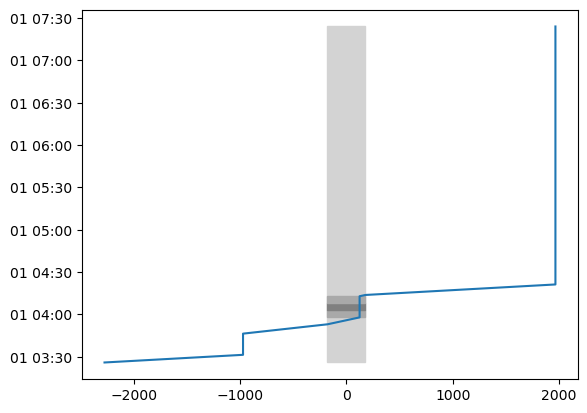

In [27]:
xlimmin = -2000
xlimmax = 2000

# We can plot the time-distance diagram
fig,ax = plt.subplots()

Volkerak.create_time_distance_plot([vessel_1], xlimmin = xlimmin, xlimmax = xlimmax, ax = ax, label='modelled')

plt.show()

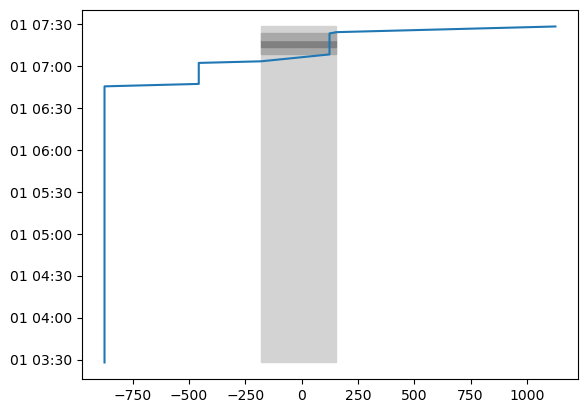

In [28]:
fig,ax = plt.subplots()

Kreekrak.create_time_distance_plot([vessel_1], xlimmin = xlimmin, xlimmax = xlimmax, ax = ax, label='modelled')

plt.show()

### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [29]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

pd.set_option('display.max_rows', None)
display(df)

'M9 Vessel passing OM+RS V+K' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 8861716 to node B17838816_B ...,2024-01-01 00:00:00.000000,0,POINT (4.32003340516321 51.8944476699094)
1,Sailing from node 8861716 to node B17838816_B ...,2024-01-01 00:11:11.550698,2686.202792,POINT (4.331101754547955 51.87131584461907)
2,Sailing from node B17838816_B to node B1783881...,2024-01-01 00:11:11.550698,2686.202792,POINT (4.331101754547955 51.87131584461907)
3,Sailing from node B17838816_B to node B1783881...,2024-01-01 00:11:14.127663,2696.510652,POINT (4.331149675825261 51.871228074742795)
4,Sailing from node B17838816_A to node 8865803 ...,2024-01-01 00:11:14.127663,2696.510652,POINT (4.331149675825261 51.871228074742795)
5,Sailing from node B17838816_A to node 8865803 ...,2024-01-01 00:13:20.678346,3202.713384,POINT (4.33350300310146 51.866917854826305)
6,Sailing from node 8865803 to node 8862143 start,2024-01-01 00:13:20.678346,3202.713384,POINT (4.33350300310146 51.866917854826305)
7,Sailing from node 8865803 to node 8862143 stop,2024-01-01 00:14:41.633785,3526.535139,POINT (4.33506263254959 51.864172165469505)
8,Sailing from node 8862143 to node B42792_B start,2024-01-01 00:14:41.633785,3526.535139,POINT (4.33506263254959 51.864172165469505)
9,Sailing from node 8862143 to node B42792_B stop,2024-01-01 00:17:15.111488,4140.445951,POINT (4.340053200020321 51.859600597806946)


The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [30]:
df_eventtable = logbook2eventtable([vessel_1])
df_eventtable

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698
1,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965
2,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683
3,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439
4,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703
5,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B42792_B to node B42792_A,,POINT (4.340053200020321 51.859600597806946),POINT (4.340125260900426 51.859531369318596),2024-01-01 00:17:15,2024-01-01 00:17:17,9.168936,2.292234
6,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B42792_A to node 8867784,,POINT (4.340125260900426 51.859531369318596),POINT (4.34220631701808 51.8572692964818),2024-01-01 00:17:17,2024-01-01 00:18:30,289.645631,72.411408
7,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8867784 to node 8864737,,POINT (4.34220631701808 51.8572692964818),POINT (4.43200716599724 51.8367377400882),2024-01-01 00:18:30,2024-01-01 00:47:36,6984.781815,1746.195453
8,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8864737 to node 8867023,,POINT (4.43200716599724 51.8367377400882),POINT (4.52760808152354 51.8302649043596),2024-01-01 00:47:36,2024-01-01 01:16:12,6865.180650,1716.295163
9,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8867023 to node 8863810,,POINT (4.52760808152354 51.8302649043596),POINT (4.56623163072507 51.812486619297296),2024-01-01 01:16:12,2024-01-01 01:33:06,4054.016523,1013.504130


In [31]:
# add energy attributes to the minimum event table
df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel_1])        
df_eventtable_energy = add_lock_chamber_dimensions_in_energy_eventtable(df_eventtable_energy, env)
# pd.set_option('display.max_columns', None)
df_eventtable_energy

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh)
0,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698,6.0,None,0.0,619.443950,619.443950,1750.0,115.552227
1,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965,6.0,None,0.0,619.443923,619.443923,1750.0,0.443413
2,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683,6.0,None,0.0,619.443948,619.443948,1750.0,21.775293
3,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439,6.0,None,0.0,619.443946,619.443946,1750.0,13.929821
4,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703,6.0,None,0.0,619.443950,619.443950,1750.0,26.408565
5,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B42792_B to node B42792_A,,POINT (4.340053200020321 51.859600597806946),POINT (4.340125260900426 51.859531369318596),2024-01-01 00:17:15,2024-01-01 00:17:17,9.168936,2.292234,6.0,None,0.0,619.443968,619.443968,1750.0,0.394420
6,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B42792_A to node 8867784,,POINT (4.340125260900426 51.859531369318596),POINT (4.34220631701808 51.8572692964818),2024-01-01 00:17:17,2024-01-01 00:18:30,289.645631,72.411408,6.0,None,0.0,619.443946,619.443946,1750.0,12.459669
7,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8867784 to node 8864737,,POINT (4.34220631701808 51.8572692964818),POINT (4.43200716599724 51.8367377400882),2024-01-01 00:18:30,2024-01-01 00:47:36,6984.781815,1746.195453,6.0,None,0.0,619.443951,619.443951,1750.0,300.463947
8,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8864737 to node 8867023,,POINT (4.43200716599724 51.8367377400882),POINT (4.52760808152354 51.8302649043596),2024-01-01 00:47:36,2024-01-01 01:16:12,6865.180650,1716.295163,6.0,None,0.0,619.443949,619.443949,1750.0,295.319071
9,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8867023 to node 8863810,,POINT (4.52760808152354 51.8302649043596),POINT (4.56623163072507 51.812486619297296),2024-01-01 01:16:12,2024-01-01 01:33:06,4054.016523,1013.504130,6.0,None,0.0,619.443952,619.443952,1750.0,174.391390


In [32]:
# add fuel attributes to the minimum event table with energy attributes
df_eventtable_energy_fuel = add_fuel_attributes_to_event_table(df_eventtable_energy, [vessel_1])

pd.set_option('display.max_columns', None)
df_eventtable_energy_fuel

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),diesel_consumption (g),diesel_consumption_m (g/m),diesel_consumption_s (g/s),CO2_emission_total (g),PM10_emission_total (g),NOX_emission_total (g),CO2_emission_per_m (g/m),PM10_emission_per_m (g/m),NOX_emission_per_m (g/m),CO2_emission_per_s (g/s),PM10_emission_per_s (g/s),NOX_emission_per_s (g/s)
0,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698,6.0,None,0.0,619.443950,619.443950,1750.0,115.552227,27669.075341,10.300442,41.201767,87786.429945,48.458574,1201.163632,32.680492,0.018040,0.447160,130.721970,0.072159,1.788642
1,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965,6.0,None,0.0,619.443923,619.443923,1750.0,0.443413,106.175507,10.300441,41.201765,336.865926,0.185952,4.609267,32.680491,0.018040,0.447160,130.721964,0.072159,1.788642
2,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683,6.0,None,0.0,619.443948,619.443948,1750.0,21.775293,5214.111727,10.300442,41.201767,16542.954480,9.131798,226.353837,32.680492,0.018040,0.447160,130.721969,0.072159,1.788642
3,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439,6.0,None,0.0,619.443946,619.443946,1750.0,13.929821,3335.507108,10.300442,41.201767,10582.654370,5.841681,144.800279,32.680492,0.018040,0.447160,130.721969,0.072159,1.788642
4,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703,6.0,None,0.0,619.443950,619.443950,1750.0,26.408565,6323.552544,10.300442,41.201767,20062.907616,11.074831,274.516631,32.680492,0.018040,0.447160,130.721970,0.072159,1.788642
5,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B42792_B to node B42792_A,,POINT (4.340053200020321 51.859600597806946),POINT (4.340125260900426 51.859531369318596),2024-01-01 00:17:15,2024-01-01 00:17:17,9.168936,2.292234,6.0,None,0.0,619.443968,619.443968,1750.0,0.394420,94.444094,10.300442,41.201768,299.645352,0.165406,4.099986,32.680493,0.018040,0.447160,130.721973,0.072159,1.788642
6,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B42792_A to node 8867784,,POINT (4.340125260900426 51.859531369318596),POINT (4.34220631701808 51.8572692964818),2024-01-01 00:17:17,2024-01-01 00:18:30,289.645631,72.411408,6.0,None,0.0,619.443946,619.443946,1750.0,12.459669,2983.477934,10.300442,41.201767,9465.761808,5.225151,129.518068,32.680492,0.018040,0.447160,130.721969,0.072159,1.788642
7,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8867784 to node 8864737,,POINT (4.34220631701808 51.8572692964818),POINT (4.43200716599724 51.8367377400882),2024-01-01 00:18:30,2024-01-01 00:47:36,6984.781815,1746.195453,6.0,None,0.0,619.443951,619.443951,1750.0,300.463947,71946.338157,10.300442,41.201767,228266.109243,126.004101,3123.318136,32.680492,0.018040,0.447160,130.72

In [33]:
# Trying to include the new H2 table
# add H2 attributes to the minimum event table with energy attributes
df_eventtable_energy_H2 = add_H2_attributes_to_event_table(df_eventtable_energy, [vessel_1])

pd.set_option('display.max_columns', None)
df_eventtable_energy_H2

,object id,object name,main activity name,subactivity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),diesel_consumption (g),diesel_consumption_m (g/m),diesel_consumption_s (g/s),CO2_emission_total (g),PM10_emission_total (g),NOX_emission_total (g),CO2_emission_per_m (g/m),PM10_emission_per_m (g/m),NOX_emission_per_m (g/m),CO2_emission_per_s (g/s),PM10_emission_per_s (g/s),NOX_emission_per_s (g/s),H2_consumption (g),H2_consumption_m (g/m),H2_consumption_s (g/s)
0,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8861716 to node B17838816_B,,POINT (4.32003340516321 51.8944476699094),POINT (4.331101754547955 51.87131584461907),2024-01-01 00:00:00,2024-01-01 00:11:12,2686.202792,671.550698,6.0,None,0.0,619.443950,619.443950,1750.0,115.552227,27669.075341,10.300442,41.201767,87786.429945,48.458574,1201.163632,32.680492,0.018040,0.447160,130.721970,0.072159,1.788642,7967.007020,2.965899,11.863597
1,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B17838816_B to node B17838816_A,,POINT (4.331101754547955 51.87131584461907),POINT (4.331149675825261 51.871228074742795),2024-01-01 00:11:12,2024-01-01 00:11:14,10.307860,2.576965,6.0,None,0.0,619.443923,619.443923,1750.0,0.443413,106.175507,10.300441,41.201765,336.865926,0.185952,4.609267,32.680491,0.018040,0.447160,130.721964,0.072159,1.788642,30.572074,2.965899,11.863597
2,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B17838816_A to node 8865803,,POINT (4.331149675825261 51.871228074742795),POINT (4.33350300310146 51.866917854826305),2024-01-01 00:11:14,2024-01-01 00:13:21,506.202732,126.550683,6.0,None,0.0,619.443948,619.443948,1750.0,21.775293,5214.111727,10.300442,41.201767,16542.954480,9.131798,226.353837,32.680492,0.018040,0.447160,130.721969,0.072159,1.788642,1501.346331,2.965899,11.863597
3,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8865803 to node 8862143,,POINT (4.33350300310146 51.866917854826305),POINT (4.33506263254959 51.864172165469505),2024-01-01 00:13:21,2024-01-01 00:14:42,323.821755,80.955439,6.0,None,0.0,619.443946,619.443946,1750.0,13.929821,3335.507108,10.300442,41.201767,10582.654370,5.841681,144.800279,32.680492,0.018040,0.447160,130.721969,0.072159,1.788642,960.422718,2.965899,11.863597
4,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8862143 to node B42792_B,,POINT (4.33506263254959 51.864172165469505),POINT (4.340053200020321 51.859600597806946),2024-01-01 00:14:42,2024-01-01 00:17:15,613.910812,153.477703,6.0,None,0.0,619.443950,619.443950,1750.0,26.408565,6323.552544,10.300442,41.201767,20062.907616,11.074831,274.516631,32.680492,0.018040,0.447160,130.721970,0.072159,1.788642,1820.797655,2.965899,11.863597
5,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B42792_B to node B42792_A,,POINT (4.340053200020321 51.859600597806946),POINT (4.340125260900426 51.859531369318596),2024-01-01 00:17:15,2024-01-01 00:17:17,9.168936,2.292234,6.0,None,0.0,619.443968,619.443968,1750.0,0.394420,94.444094,10.300442,41.201768,299.645352,0.165406,4.099986,32.680493,0.018040,0.447160,130.721973,0.072159,1.788642,27.194142,2.965899,11.863598
6,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node B42792_A to node 8867784,,POINT (4.340125260900426 51.859531369318596),POINT (4.34220631701808 51.8572692964818),2024-01-01 00:17:17,2024-01-01 00:18:30,289.645631,72.411408,6.0,None,0.0,619.443946,619.443946,1750.0,12.459669,2983.477934,10.300442,41.201767,9465.761808,5.225151,129.518068,32.680492,0.018040,0.447160,130.721969,0.072159,1.788642,859.059775,2.965899,11.863597
7,7f809d01-97de-471d-b4c3-1b40fb4da880,M9 Vessel passing OM+RS V+K,Sailing from node 8867784 to node 8864737,,POINT (4.34220631701808 51.85

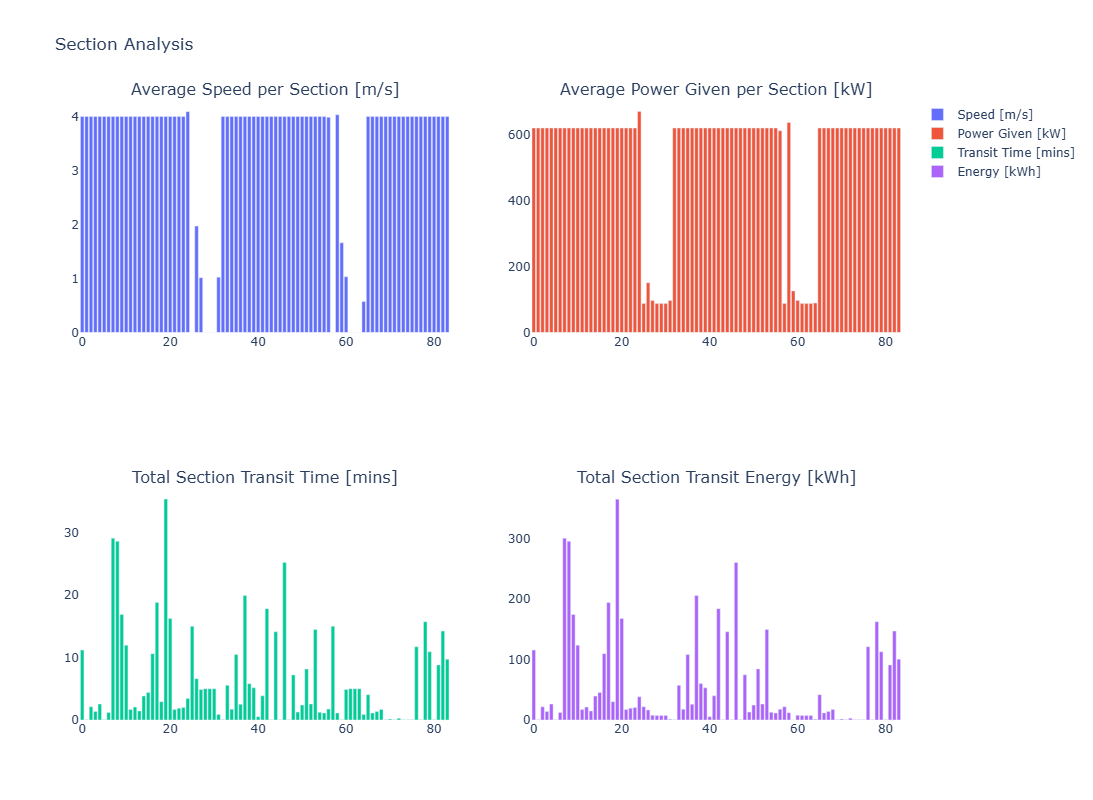

In [34]:
# Calculate average speed
average_speed = df_eventtable_energy_fuel['distance (m)'] / df_eventtable_energy_fuel['duration (s)']

# Calculate durations in minutes
durations = [
    (row['stop time'] - row['start time']).total_seconds() / 60
    for _, row in df_eventtable_energy_fuel.iterrows()
]

# Create 2x2 subplot figure
fig = make_subplots(rows=2, cols=2, subplot_titles=[
    'Average Speed per Section [m/s]',
    'Average Power Given per Section [kW]',
    'Total Section Transit Time [mins]',
    'Total Section Transit Energy [kWh]'
])

# Add bar charts to subplots
fig.add_trace(go.Bar(x=df.index, y=average_speed, name='Speed [m/s]'), row=1, col=1)
fig.add_trace(go.Bar(x=df.index, y=df_eventtable_energy_fuel['P_given (kW)'], name='Power Given [kW]'), row=1, col=2)
fig.add_trace(go.Bar(x=df.index, y=durations, name='Transit Time [mins]'), row=2, col=1)
fig.add_trace(go.Bar(x=df.index, y=df_eventtable_energy_fuel['total_energy (kWh)'], name='Energy [kWh]'), row=2, col=2)

# Update layout
fig.update_layout(
    height=800,
    width=1000,
    title_text='Section Analysis',
    plot_bgcolor='white'
)

# fig.show()

In [35]:
# Event totals + unit conversion + speed 
df_event = (
    df_eventtable
    .groupby('object name')
    .agg({'duration (s)': 'sum', 'distance (m)': 'sum'})
)
df_event['duration (h)']      = df_event['duration (s)'] / 3600
df_event['distance (km)']     = df_event['distance (m)'] / 1000
df_event['avg_speed_m_s']     = df_event['distance (m)'] / df_event['duration (s)']
# df_event['avg_speed_km_h']    = df_event['avg_speed_m_s'] * 3.6

# Diesel energy & fuel
df_fuel = (
    df_eventtable_energy_fuel
    .groupby('object name')
    .agg({'total_energy (kWh)': 'sum', 'diesel_consumption (g)': 'sum'})
)
df_fuel['diesel_consumption (kg)'] = df_fuel['diesel_consumption (g)'] / 1000
 
# H2 energy & fuel
df_H2 = (
    df_eventtable_energy_H2
    .groupby('object name')
    .agg({'total_energy (kWh)': 'sum', 'H2_consumption (g)': 'sum'})
)
df_H2['H2_consumption (kg)'] = df_H2['H2_consumption (g)'] / 1000

# Final summary table
summary = (
    df_event[['duration (h)', 'distance (km)', 'avg_speed_m_s']]
    .join(df_fuel[['total_energy (kWh)', 'diesel_consumption (kg)']])
    .join(df_H2[['H2_consumption (kg)']])
)

summary

,duration (h),distance (km),avg_speed_m_s,total_energy (kWh),diesel_consumption (kg),H2_consumption (kg)
object name,,,,,,
M9 Vessel passing OM+RS V+K,8.732483,108.46307,3.450179,4727.325151,1131.961877,325.936017


In [36]:
print("P_partial =", vessel_1.P_partial)
print("C_partial_load_PEMFC =", vessel_1.C_partial_load_PEMFC)

# Curious if this works too but it doesn't yet
# print("total_LH2_consumption_PEMFC_mass =", vessel_1.total_LH2_consumption_PEMFC_mass)

P_partial = 0.35396797149565107
C_partial_load_PEMFC = 1.033174377196521
